In [15]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')  

import nltk

In [16]:
import os
os.chdir('C:/Users/jialuzha.stu/OneDrive - UBC/Desktop/MGEM Capstone/John_Hendry_Park_Test')

df = pd.read_excel('C:/Users/jialuzha.stu/OneDrive - UBC/Desktop/MGEM Capstone/John_Hendry_Park_Test/Data/Processed_Output/John_Hendry_Park_Clean.xlsx')
print(df.head()) 
print(df.shape)

   review_id                                name   author_title  \
0          1  John Hendry Park (Trout Lake Park)  Lucas Clearly   
1          2  John Hendry Park (Trout Lake Park)       sowjanya   
2          3  John Hendry Park (Trout Lake Park)     Rania Tan.   
3          4  John Hendry Park (Trout Lake Park)       Anson Li   
4          5  John Hendry Park (Trout Lake Park)    Karin Hatch   

               author_id                                        review_text  \
0  115109798485437495979  "Visited John Hendry Park (Trout Lake Park) to...   
1  100601097379534923033  A beautiful park , I love going in the fall se...   
2  116635854122359369671  A beautiful park with a pond, playground and r...   
3  118252211920789680978  A circular track good for walking, biking, jog...   
4  116725000188867424887  A decent and well attended community city park...   

   review_rating  review_datetime_utc review_questions_None  
0              5  06/12/2024 10:42:27                   NaN 

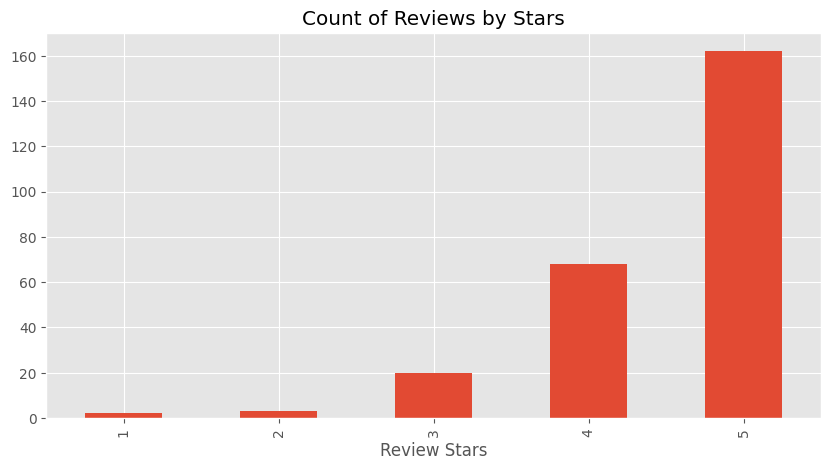

In [17]:
#Plot number of reviews for each star score 
ax = df['review_rating'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Count of Reviews by Stars',
          figsize=(10, 5))
ax.set_xlabel('Review Stars')
plt.show()

Note: Average Rating 4.6 from a total of 3870 reviews - this subsample only contains 255 filtered reviews 


In [18]:
#translate non-english reviews 
from deep_translator import GoogleTranslator
translator = GoogleTranslator()

# Function to translate non-English reviews to English using deep_translator
def translate_review(text):
    return GoogleTranslator(source='auto', target='en').translate(text) #auto language detection

# Apply translation function to 'review_text' column and add the result as a new column
df['translated_text'] = df['review_text'].apply(translate_review)

# Display the updated DataFrame
print(df)



     review_id                                name   author_title  \
0            1  John Hendry Park (Trout Lake Park)  Lucas Clearly   
1            2  John Hendry Park (Trout Lake Park)       sowjanya   
2            3  John Hendry Park (Trout Lake Park)     Rania Tan.   
3            4  John Hendry Park (Trout Lake Park)       Anson Li   
4            5  John Hendry Park (Trout Lake Park)    Karin Hatch   
..         ...                                 ...            ...   
250        251  John Hendry Park (Trout Lake Park)      Keith Yun   
251        252  John Hendry Park (Trout Lake Park)      Sam Leung   
252        253  John Hendry Park (Trout Lake Park)       Ms Huang   
253        254  John Hendry Park (Trout Lake Park)       Khelim C   
254        255  John Hendry Park (Trout Lake Park)            吉达星   

                 author_id                                        review_text  \
0    115109798485437495979  "Visited John Hendry Park (Trout Lake Park) to...   
1    1006

Step 1 - Natural Language Toolkit (NLTK) Approach 

In [19]:
#Lets look at one example 
example = df['review_text'][10]
print(example)

Absolutely amazing experience. It is a hidden gem in Vancouver, offering a delightful blend of natural beauty, recreational activities, and a welcoming community atmosphere. For your recreational activities and a peaceful retreat, or a place to connect to the nature and community, it is a fantastic destination to be. It is a best place with a lake and nature blend. I highly recommend visiting the place and experience it's serenity.


In [20]:

#tokenizing the text and list first 10 tokens
tokens = nltk.word_tokenize(example)
print(tokens [:10])

['Absolutely', 'amazing', 'experience', '.', 'It', 'is', 'a', 'hidden', 'gem', 'in']


POS - Parts of Speech Tagging 

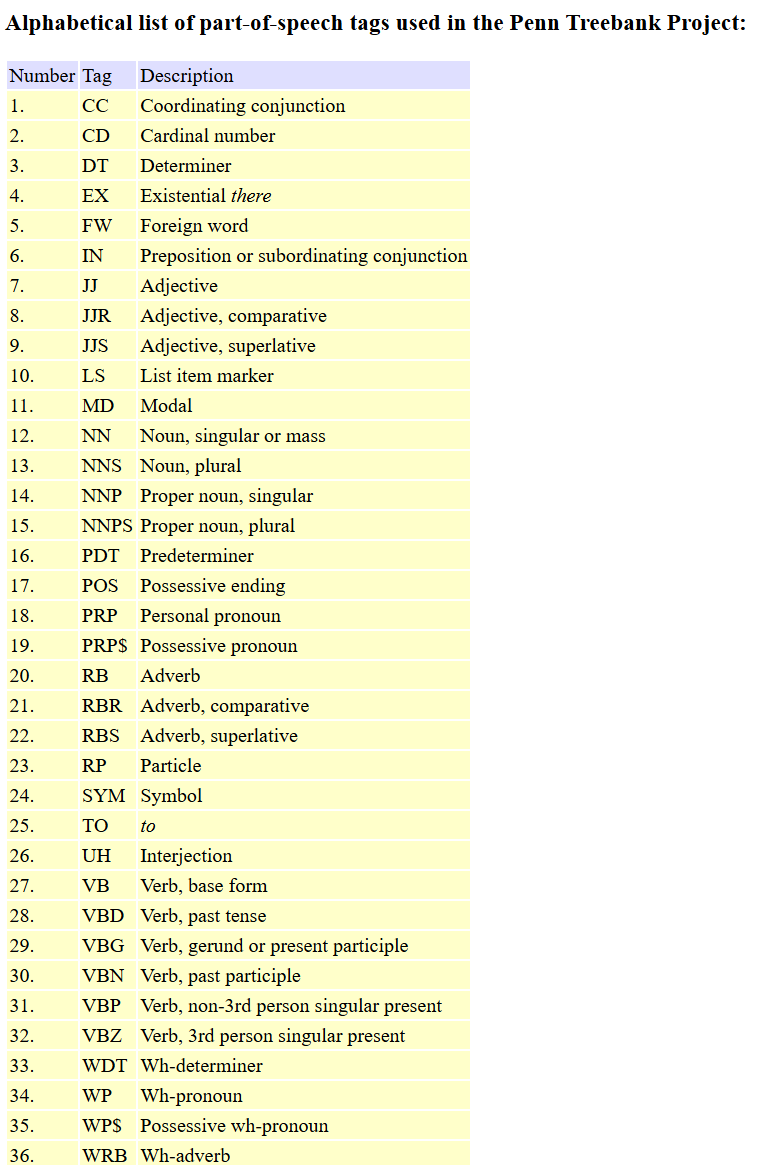

In [21]:
from IPython.display import Image

# Display image
Image(filename='C:/Users/jialuzha.stu/OneDrive - UBC/Desktop/MGEM Capstone/NLTK_Test/POS Tags.png')

In [22]:
#tagging each token - each noun receives Part of Speech (POS) tag --> https://www.ling.upenn.edu/courses/Fall_2003/ling001/penn_treebank_pos.html
tagged = nltk.pos_tag(tokens)
print(tagged[:10])

[('Absolutely', 'RB'), ('amazing', 'JJ'), ('experience', 'NN'), ('.', '.'), ('It', 'PRP'), ('is', 'VBZ'), ('a', 'DT'), ('hidden', 'JJ'), ('gem', 'NN'), ('in', 'IN')]


In [23]:
#Chunk the tagged entities into sentences 
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  Absolutely/RB
  amazing/JJ
  experience/NN
  ./.
  It/PRP
  is/VBZ
  a/DT
  hidden/JJ
  gem/NN
  in/IN
  (GPE Vancouver/NNP)
  ,/,
  offering/VBG
  a/DT
  delightful/JJ
  blend/NN
  of/IN
  natural/JJ
  beauty/NN
  ,/,
  recreational/JJ
  activities/NNS
  ,/,
  and/CC
  a/DT
  welcoming/NN
  community/NN
  atmosphere/RB
  ./.
  For/IN
  your/PRP$
  recreational/JJ
  activities/NNS
  and/CC
  a/DT
  peaceful/JJ
  retreat/NN
  ,/,
  or/CC
  a/DT
  place/NN
  to/TO
  connect/VB
  to/TO
  the/DT
  nature/NN
  and/CC
  community/NN
  ,/,
  it/PRP
  is/VBZ
  a/DT
  fantastic/JJ
  destination/NN
  to/TO
  be/VB
  ./.
  It/PRP
  is/VBZ
  a/DT
  best/JJ
  place/NN
  with/IN
  a/DT
  lake/NN
  and/CC
  nature/JJ
  blend/NN
  ./.
  I/PRP
  highly/RB
  recommend/VBP
  visiting/VBG
  the/DT
  place/NN
  and/CC
  experience/NN
  it/PRP
  's/VBZ
  serenity/NN
  ./.)


In [24]:

from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

#testing using a positive sentence 
print('I am so happy!') 
print(sia.polarity_scores('I am so happy!'))

#testing with a neutral sentence 
print('We are out of granola bars if you see any on sale')
print(sia.polarity_scores('We are out of granola bars if you see any on sale'))

#testing with a negative sentence 
print('I really hate the parks in Vancouver')
print(sia.polarity_scores('I really hate the parks in Vancouver'))

#testing with example review: 
print(example)
print(sia.polarity_scores(example))


I am so happy!
{'neg': 0.0, 'neu': 0.318, 'pos': 0.682, 'compound': 0.6468}
We are out of granola bars if you see any on sale
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
I really hate the parks in Vancouver
{'neg': 0.444, 'neu': 0.556, 'pos': 0.0, 'compound': -0.6115}
Absolutely amazing experience. It is a hidden gem in Vancouver, offering a delightful blend of natural beauty, recreational activities, and a welcoming community atmosphere. For your recreational activities and a peaceful retreat, or a place to connect to the nature and community, it is a fantastic destination to be. It is a best place with a lake and nature blend. I highly recommend visiting the place and experience it's serenity.
{'neg': 0.0, 'neu': 0.609, 'pos': 0.391, 'compound': 0.9857}


In [25]:

#for loop to run polarity score on the dataframe, initiated dictionary to store results 
res = {}
for i, row in df.iterrows():
    text = row['translated_text']
    myid = row['review_id']
    if text is None or pd.isna(text):  # Check for None or NaN
        text = ""  # Replace with empty string or skip the row
    res[myid] = sia.polarity_scores(text)
    
    # Print progress every 50 rows 
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Processed {i + 1}/{len(df)} reviews.")
print("Sentiment analysis completed for all reviews.")

Processed 50/255 reviews.
Processed 100/255 reviews.
Processed 150/255 reviews.
Processed 200/255 reviews.
Processed 250/255 reviews.
Processed 255/255 reviews.
Sentiment analysis completed for all reviews.


Note: VADER computes the compound score as a normalized sum of the sentiment for individual words in the sentence, then adjusted for degree modifiers (ex: very, extremely, but). Final score is between -1 and 1, reflecting the overall sentiment. 

In [26]:
#organizing result scores in a pandas dataframe
vaders = pd.DataFrame(res).T #pivot dataframe
vaders = vaders.reset_index().rename(columns={'index': 'review_id'}) #Merge results onto original dataframe, on the left side 
vaders = vaders.merge(df, how='left') 
print(vaders.head()) #Check to see scores have been added 

   review_id  neg    neu    pos  compound                                name  \
0          1  0.0  0.452  0.548    0.9719  John Hendry Park (Trout Lake Park)   
1          2  0.0  0.677  0.323    0.8442  John Hendry Park (Trout Lake Park)   
2          3  0.0  0.606  0.394    0.5994  John Hendry Park (Trout Lake Park)   
3          4  0.0  0.931  0.069    0.4404  John Hendry Park (Trout Lake Park)   
4          5  0.0  0.706  0.294    0.8625  John Hendry Park (Trout Lake Park)   

    author_title              author_id  \
0  Lucas Clearly  115109798485437495979   
1       sowjanya  100601097379534923033   
2     Rania Tan.  116635854122359369671   
3       Anson Li  118252211920789680978   
4    Karin Hatch  116725000188867424887   

                                         review_text  review_rating  \
0  "Visited John Hendry Park (Trout Lake Park) to...              5   
1  A beautiful park , I love going in the fall se...              4   
2  A beautiful park with a pond, playgrou

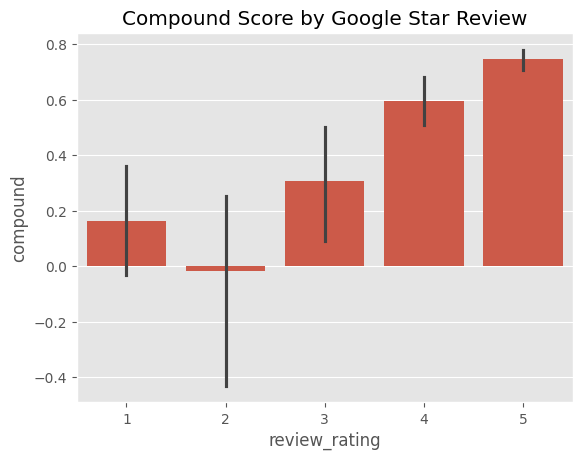

In [27]:
#vader results - validate with star rating 
ax = sns.barplot(data=vaders, x='review_rating', y='compound')
ax.set_title('Compound Score by Google Star Review')
plt.show()

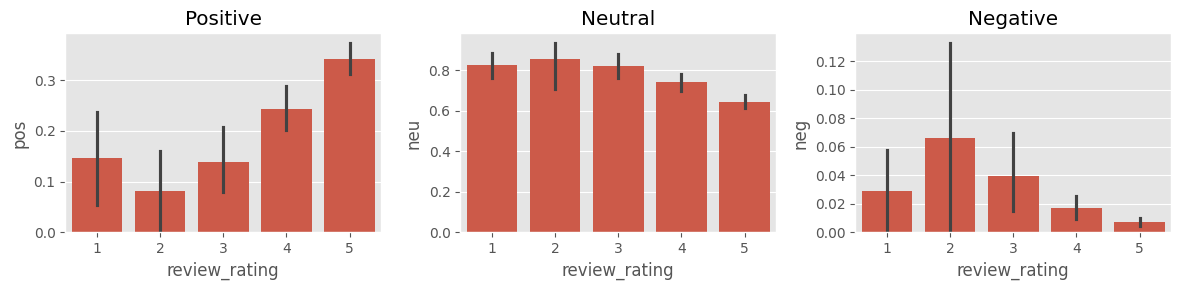

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='review_rating', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='review_rating', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='review_rating', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

BERT Test - Using pre-trained RoBERTA model trained on twitter data 

In [29]:
#Load in BERT model from Hugging Faces Library 
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification #Choosing specific model - this is a generic model class. Adjust weights using from_pretrained()
from scipy.special import softmax #apply softmax smooth output values between 0 and 1

In [30]:
#Load in Pre-trained MODEL --> RoBERTa and its stored attention weights --> transfer learning approach
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

#Making a function from model, with the score dictionary as result 
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores) #applying softmax to get probabilities 
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

In [31]:
# for loop to run function for entire dataset
res = {}
for i, row in df.iterrows():
    text = row['translated_text']
    myid = row['review_id']
    
# Perform VADER sentiment analysis

# Skip rows with invalid text
    if not text or not isinstance(text, str):
        print(f"Skipping review {myid} due to invalid text.")
        continue

    vader_result = sia.polarity_scores(text)
    vader_result_rename = {}
    for key, value in vader_result.items():
        vader_result_rename[f"vader_{key}"] = value

    # Perform RoBERTa sentiment analysis
    roberta_result = polarity_scores_roberta(text)
    
    both = {**vader_result_rename, **roberta_result}
    
    # Combine results (example)
    res[myid] = both

    # Print progress
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Processed {i + 1}/{len(df)} reviews.")

print("Sentiment analysis completed for all reviews.")


Processed 50/255 reviews.
Processed 100/255 reviews.
Processed 150/255 reviews.
Processed 200/255 reviews.
Skipping review 219 due to invalid text.
Processed 250/255 reviews.
Processed 255/255 reviews.
Sentiment analysis completed for all reviews.


In [32]:
# Combine results from both models into one dataframe, linked by review_id
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'review_id'})
results_df = results_df.merge(df, how='left')
results_df.columns #checking the merge worked 
results_df.head()

,review_id,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos,name,author_title,author_id,review_text,review_rating,review_datetime_utc,review_questions_None,translated_text
0,1,0.0,0.452,0.548,0.9719,0.001178,0.009673,0.989149,John Hendry Park (Trout Lake Park),Lucas Clearly,115109798485437495979,"""Visited John Hendry Park (Trout Lake Park) to...",5,06/12/2024 10:42:27,NaN,"""Visited John Hendry Park (Trout Lake Park) to..."
1,2,0.0,0.677,0.323,0.8442,0.000977,0.010587,0.988436,John Hendry Park (Trout Lake Park),sowjanya,100601097379534923033,"A beautiful park , I love going in the fall se...",4,11/07/2022 06:13:38,NaN,"A beautiful park , I love going in the fall se..."
2,3,0.0,0.606,0.394,0.5994,0.002246,0.051468,0.946286,John Hendry Park (Trout Lake Park),Rania Tan.,116635854122359369671,"A beautiful park with a pond, playground and r...",5,08/29/2023 04:17:52,NaN,"A beautiful park with a pond, playground and r..."
3,4,0.0,0.931,0.069,0.4404,0.001918,0.168206,0.829876,John Hendry Park (Trout Lake Park),Anson Li,118252211920789680978,"A circular track good for walking, biking, jog...",4,06/23/2023 02:52:52,NaN,"A circular track good for walking, biking, jog..."
4,5,0.0,0.706,0.294,0.8625,0.001944,0.014466,0.983590,John Hendry Park (Trout Lake Park),Karin Hatch,116725000188867424887,A decent and well attended community city park...,4,09/18/2021 20:36:46,NaN,A decent and well attended community city park...


Noticed that roberta_compound column is missing? This is because the model does not natively output a single compound score, the scores represent how confident the model is about the input text belonging in one of the three sentiment categories. But we can calculate a weighted score:

In [33]:
# Define sentiment weights for roberta: +1 for positive, 0 for neutral, -1 for negative
sentiment_weights = np.array([-1, 0, 1])  # weights for negative, neutral, positive

# Function to calculate roberta compound score
def calculate_roberta_compound(row):
    roberta_scores = np.array([row['roberta_neg'], row['roberta_neu'], row['roberta_pos']])
    # Calculate compound score using weighted sum: (negative * -1) + (neutral * 0) + (positive * 1)
    return np.dot(roberta_scores, sentiment_weights)

# Apply the function to each row and create a new column for roberta_compound score
results_df['roberta_compound'] = results_df.apply(calculate_roberta_compound, axis=1)

print(results_df.columns)

Index(['review_id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'name', 'author_title',
       'author_id', 'review_text', 'review_rating', 'review_datetime_utc',
       'review_questions_None', 'translated_text', 'roberta_compound'],
      dtype='object')


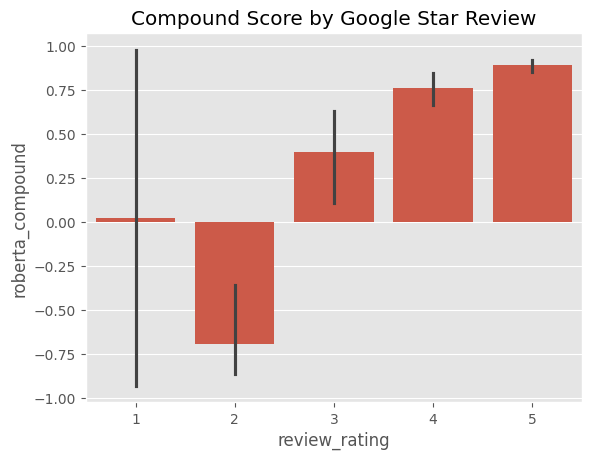

In [34]:
#RoBERTa results -- plot against star rating for validation 
ax = sns.barplot(data=results_df, x='review_rating', y=results_df['roberta_compound'])
ax.set_title('Compound Score by Google Star Review')
plt.show()

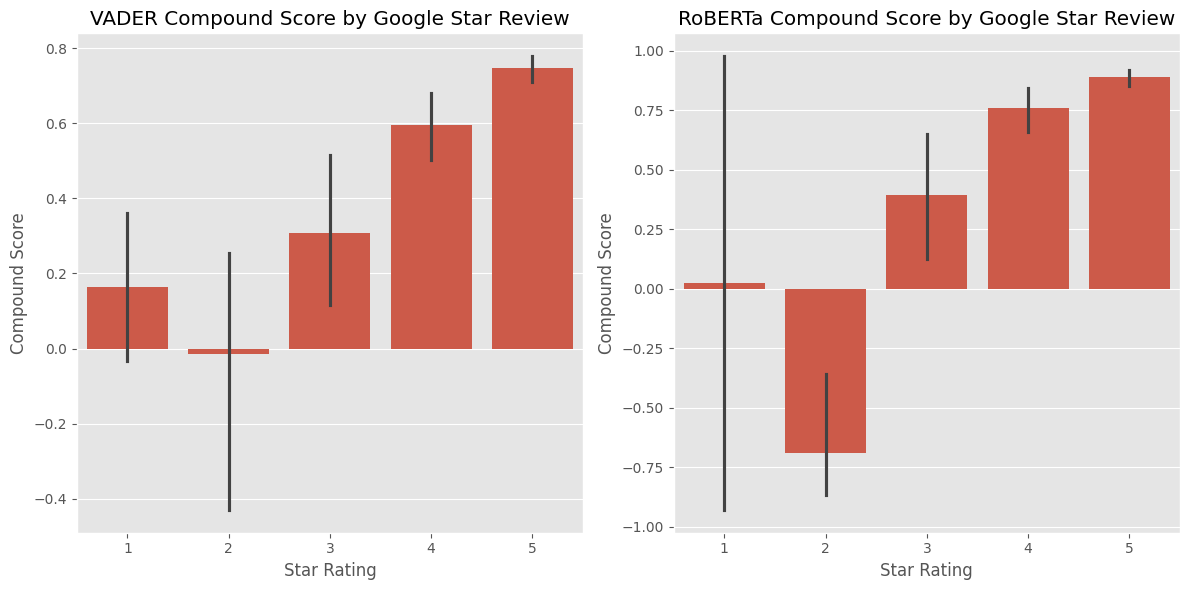

In [35]:

fig, ax = plt.subplots(1, 2, figsize=(12, 6))  

# VADER results - plot against star rating
sns.barplot(data=vaders, x='review_rating', y='compound', ax=ax[0])
ax[0].set_title('VADER Compound Score by Google Star Review')
ax[0].set_xlabel('Star Rating')
ax[0].set_ylabel('Compound Score')

# RoBERTa results - plot against star rating
sns.barplot(data=results_df, x='review_rating', y='roberta_compound', ax=ax[1])
ax[1].set_title('RoBERTa Compound Score by Google Star Review')
ax[1].set_xlabel('Star Rating')
ax[1].set_ylabel('Compound Score')

# Adjust layout
plt.tight_layout()
plt.show()


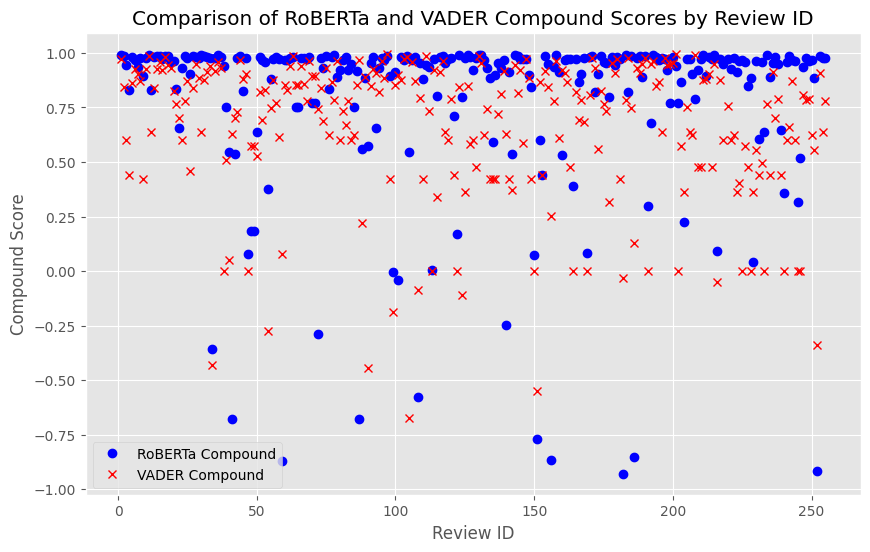

In [36]:
# Plot roberta_compound and vader_compound by review_id
plt.figure(figsize=(10, 6))
plt.plot(results_df['review_id'], results_df['roberta_compound'], label='RoBERTa Compound', marker='o', color='blue', linestyle='')  # No line
plt.plot(results_df['review_id'], results_df['vader_compound'], label='VADER Compound', marker='x', color='red', linestyle='')  # No line

plt.xlabel('Review ID')
plt.ylabel('Compound Score')
plt.title('Comparison of RoBERTa and VADER Compound Scores by Review ID')
plt.legend()

plt.show()


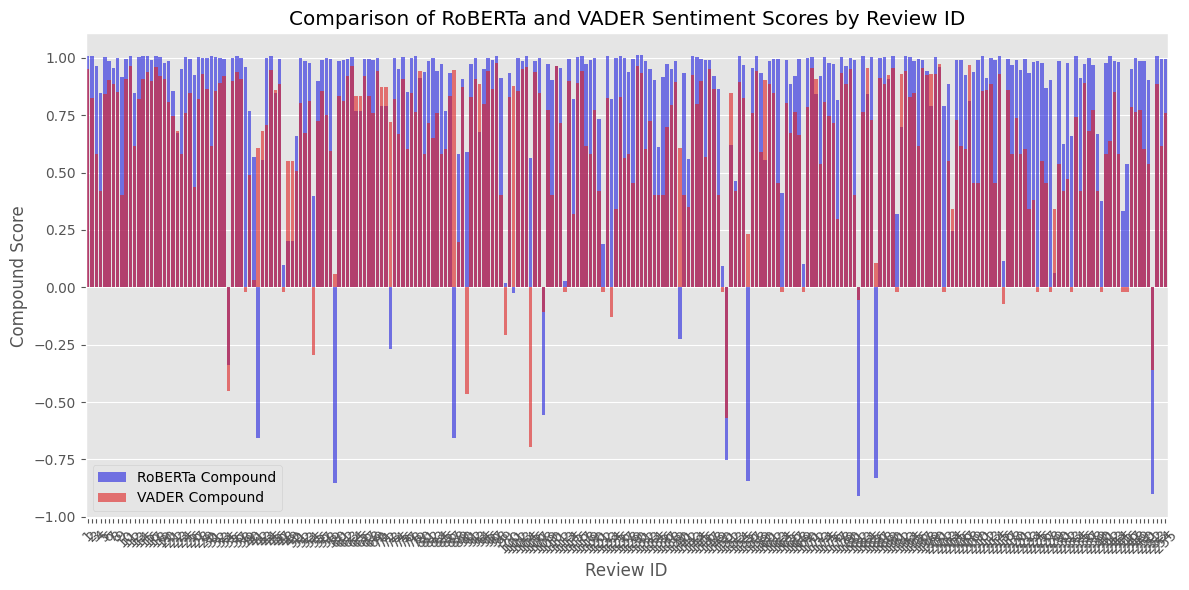

In [37]:

# Create a new column for grouping (shifted slightly for side-by-side bars)
results_df['shifted_roberta'] = results_df['roberta_compound'] + 0.02  # Adjust this to control bar width
results_df['shifted_vader'] = results_df['vader_compound'] - 0.02  # Adjust this to control bar width

# Set up the figure size
plt.figure(figsize=(12, 6))

# Plotting RoBERTa compound scores with some shift for better visualization
sns.barplot(x=results_df['review_id'], y=results_df['shifted_roberta'], color='blue', alpha=0.6, label='RoBERTa Compound')

# Plotting VADER compound scores with another shift
sns.barplot(x=results_df['review_id'], y=results_df['shifted_vader'], color='red', alpha=0.6, label='VADER Compound')

# Labels and title
plt.xlabel('Review ID')
plt.ylabel('Compound Score')
plt.title('Comparison of RoBERTa and VADER Sentiment Scores by Review ID')

# Rotate x-axis labels for better visibility if needed
plt.xticks(rotation=45)

# Add a legend
plt.legend()

# Show the plot
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


Looks like RoBERTa calculates a higher (more positive) sentiment score for reviews in general 

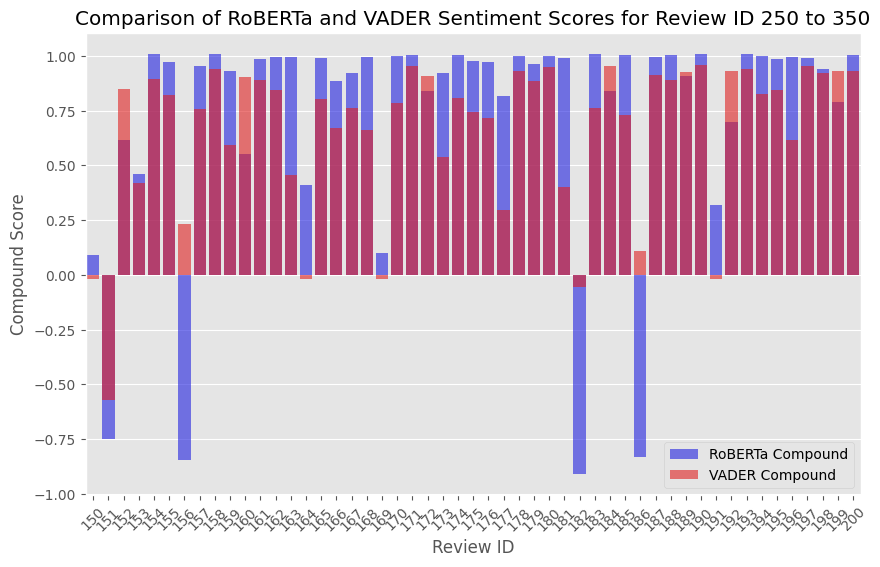

In [38]:
# Filter data to only include review_ids between 150 and 200
filtered_df = results_df[(results_df['review_id'] >= 150) & (results_df['review_id'] <= 200)]

# Create the bar plot
plt.figure(figsize=(10, 6))

# Plotting both columns with adjusted transparency
sns.barplot(x=filtered_df['review_id'], y=filtered_df['shifted_roberta'], color='blue', alpha=0.6, label='RoBERTa Compound')
sns.barplot(x=filtered_df['review_id'], y=filtered_df['shifted_vader'], color='red', alpha=0.6, label='VADER Compound')

# Labels and title
plt.xlabel('Review ID')
plt.ylabel('Compound Score')
plt.title('Comparison of RoBERTa and VADER Sentiment Scores for Review ID 250 to 350')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees

# Show the plot
plt.show()


In [39]:
#results_df.to_excel('C:/Users/jialuzha.stu/OneDrive - UBC/Desktop/MGEM Capstone/John_Hendry_Park_Test/Data/Processed_Output/John_Hendry_Park_Test_Scores.xlsx', index = False)

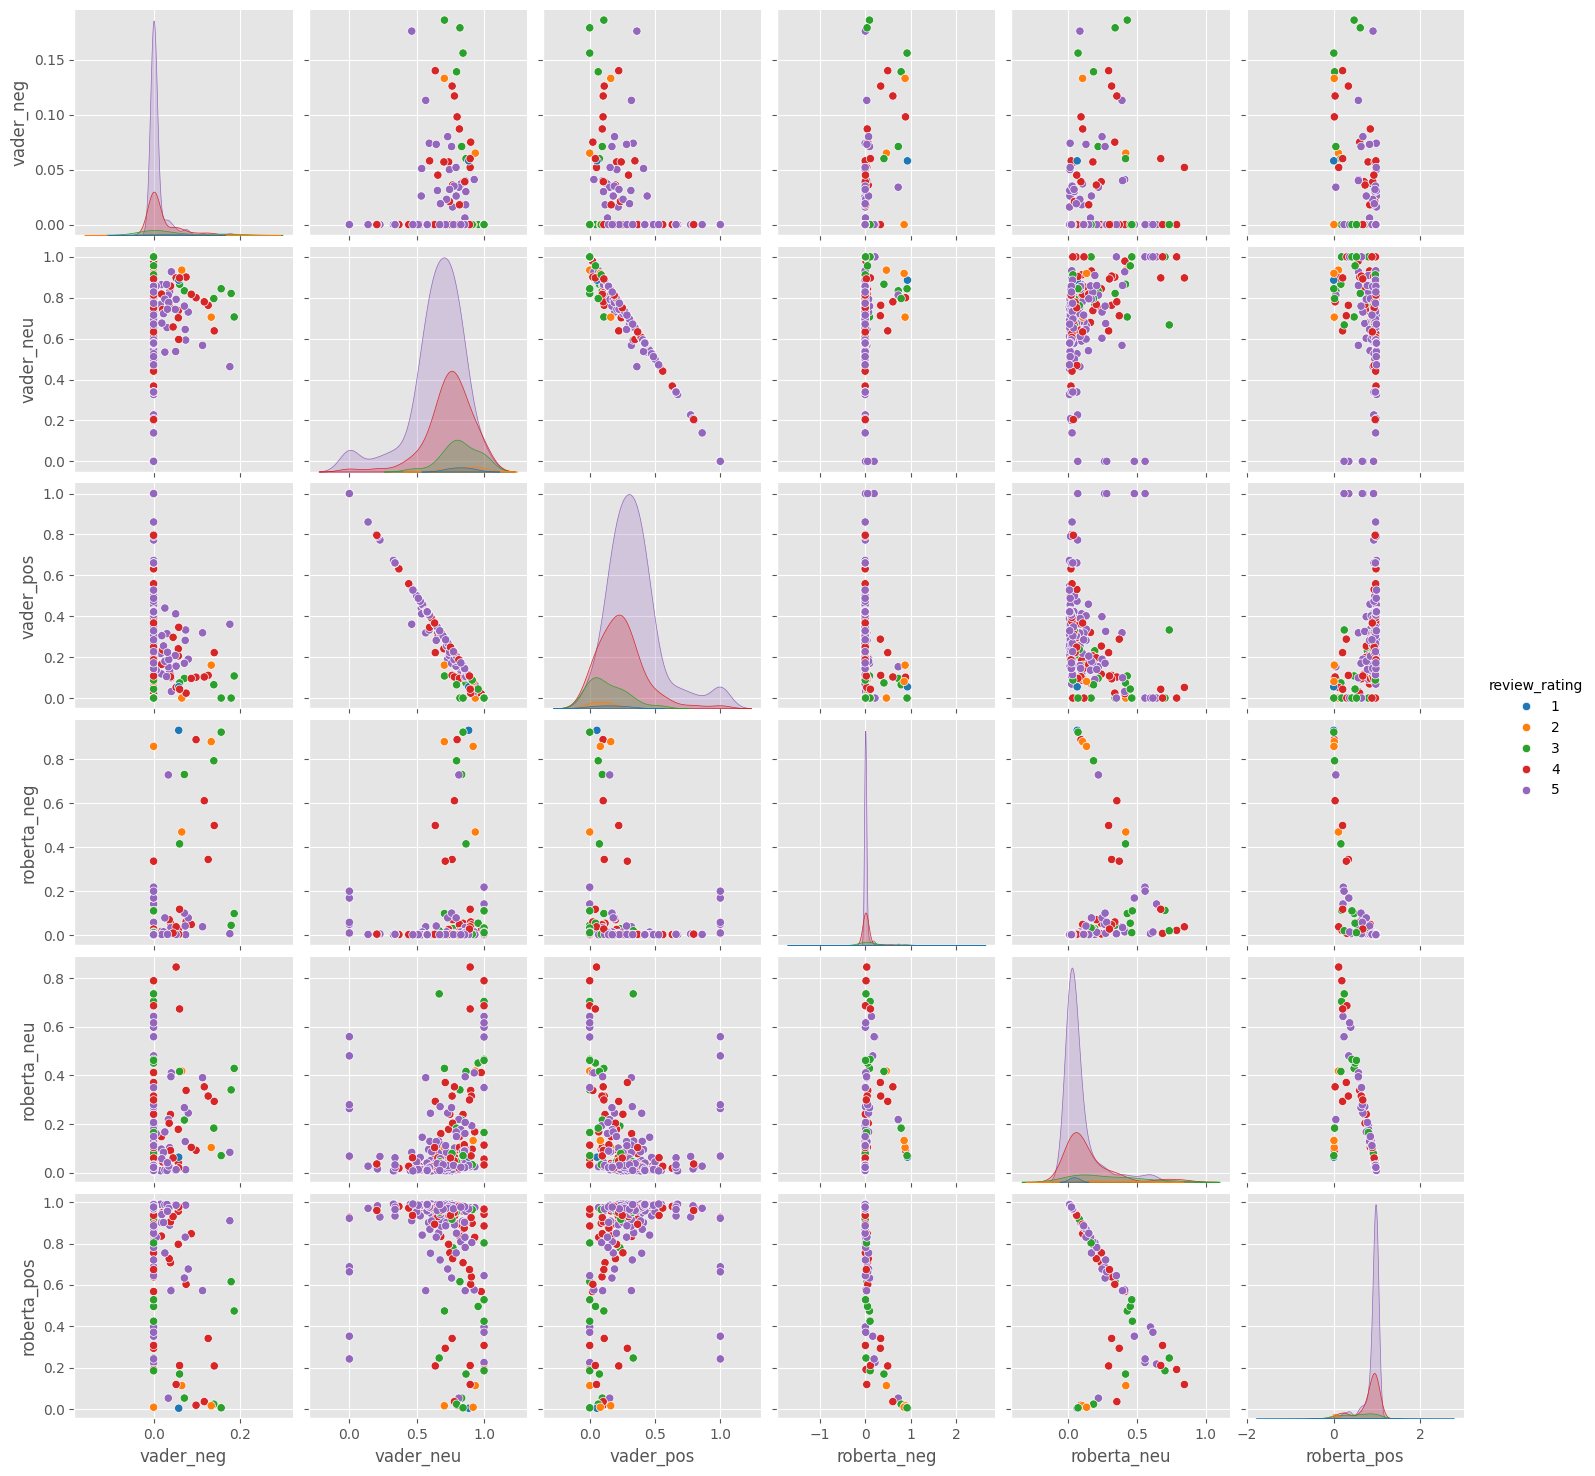

In [40]:
Matrix = sns.pairplot(data=results_df,
             vars=['vader_neg', 'vader_neu', 'vader_pos',
                  'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='review_rating',
            palette='tab10')
plt.show()



Step 4: Review Examples where Model Predictions do NOT match Star Rating 

In [41]:
#Positive 1 Star - RoBERTa
results_df.query('review_rating == 1') \
    .sort_values('roberta_pos', ascending=False) \
    .loc[:, ['review_id', 'translated_text']] \
    .values[0]
    
#This example was translated from Spanish 

array([125, "I like it, it's very big and has a family atmosphere."],
      dtype=object)

In [42]:
#Positive 1 Star - VADER
results_df.query('review_rating == 1') \
    .sort_values('vader_pos', ascending=False) \
    .loc[:, ['review_id', 'translated_text']] \
    .values[0]

array([125, "I like it, it's very big and has a family atmosphere."],
      dtype=object)

In [43]:
#Negative 5 Star - RoBERTa
results_df.query('review_rating == 5') \
    .sort_values('roberta_neg', ascending=False) \
    .loc[:, ['review_id', 'translated_text']] \
    .values[0]

array([87,
       "I have been going to this lake since I was a kid, that's over 60 yrs. As a kid we use to swim in the lake but it's not fit for swimming in for many years now. It's dog friendly and still a nice place to ride your bike or walk around or have a picnic. There is a small parking lot on the south east of the lake and north east also and west by the community centre and street parking still free!!!\nDon't tell city of Vancouver they may put meters like recently in Locarno Beach $4.00 per hr after 6pm and $1.00 per hr before 6pm. The city is not making enough money on permits etc on the mega construction going on in vancouver. Please do not meter this park vancouver is already ridiculously expensive to live in . When will they start charging for air that we breathe ha ha ."],
      dtype=object)

In [44]:
#Negative 5 Star - VADER
results_df.query('review_rating == 5') \
    .sort_values('vader_neg', ascending=False) \
    .loc[:, ['review_id', 'translated_text']] \
    .values[0]

array([26, 'Beautiful lake with a surrounding walk. Limited parking.'],
      dtype=object)

This is a beautiful city park with lots of parking around this park.  It has a free run dog park in the northern beach.
The southern beach park are open for swimming in summer.
The views are beautiful all year round.  It's good having a long of short walk around the lake or a half lake.
There are lots of people come here for fall colours.

Classification 

1. Thematic Classication - (Keyword Matching/Frequency)--> no preprocessing required, no machine learning 
Categorize review into predefined themes based on predefined labels, in this case our categories (labels) are:

1. Sense of Belonging
2. Inclusivity 
3. Safety
4. Community Interactions 

In [45]:

#Create Labels with key words --> GPT generated 200 keywords per label, casual language, non-repeating 

# Sense of Belonging Keywords
sense_of_belonging_keywords = [
    "welcoming", "comfortable", "friendly", "peaceful", "relaxed", "inviting", "warm", "community", "together", "family", "home", "supportive", 
    "open", "friendly environment", "cozy", "safe", "trust", "connected", "united", "enjoyable", "reliable", "helpful", "positive", "togetherness", 
    "caring", "great vibe", "group", "unified", "nice", "good vibes", "cheerful", "affectionate", "bond", "heartwarming", "appreciated", "harmonious", 
    "sociable", "smiling", "peaceful atmosphere", "cooperation", "calm", "homey", "support", "shared", "lovely", "affinity", "generous", "genuine", 
    "trustworthy", "safe space", "pleasant", "acceptance", "good energy", "joyful", "relaxing", "kindness", "welcoming staff", "peaceful surroundings", 
    "happy", "respectful", "engaging", "appreciation", "united", "inclusive environment", "chill", "fun", "community-oriented", "reassuring", "compassionate", 
    "friendly atmosphere", "positive experience", "engaging", "calming", "enjoyment", "reliable", "peaceful setting", "calming", "good people", "safe haven", 
    "relaxed vibe", "inviting staff", "trustworthy environment", "positive energy", "safe space", "community spirit", "shared moments", "comfortable setting", 
    "welcoming vibe", "connectedness", "together", "enjoy", "group dynamics", "family-friendly", "reliable service", "positive connections", "group vibe", 
    "supportive atmosphere", "relaxed environment", "engagement", "togetherness", "affection", "bonding", "genuine", "feel good", "safe surroundings", 
    "kind", "involved", "authentic", "mutual respect", "engaged", "helpful people", "bonded", "feel welcomed", "comfort", "secure", "family-friendly", 
    "respect", "personal connections", "community-minded", "kind-hearted", "generous", "genuine atmosphere", "welcoming people", "strong community", "shared values", 
    "good times", "communal", "home-like", "unified group", "warm atmosphere", "belonging", "warm-hearted", "together in unity", "inviting community", 
    "connected place", "together in spirit", "trusted space", "trust-based environment", "togetherness vibe", "good people", "family environment", "caring environment", 
    "open vibe", "friendly service", "positive interaction", "calm environment", "family-like atmosphere", "happy place", "genuine friendships", "heartfelt"
]

# Inclusivity Keywords
inclusivity_keywords = [
    "accessible", "everyone", "open-minded", "diverse", "equitable", "fair", "equal", "inviting", "non-discriminatory", "accommodating", "open", "respectful", 
    "inclusive", "nonjudgmental", "opportunity", "community", "all abilities", "participation", "shared", "equal treatment", "cultural", "family-friendly", 
    "open space", "shared space", "welcoming", "equal rights", "empowerment", "group activities", "acceptance", "representative", "social", "non-segregated", 
    "balanced", "respect", "unified", "welcoming environment", "diverse activities", "equal access", "teamwork", "freedom", "open to all", "non-judgmental", 
    "citizenship", "multicultural", "celebration", "openness", "integration", "shared experiences", "unity", "inclusive spaces", "community-driven", "cooperation", 
    "volunteer", "everyone included", "shared community", "mutual respect", "caring", "helpful", "equality of opportunity", "unbiased", "cultural awareness", "collaborative", 
    "social justice", "tolerant", "open to diversity", "equal footing", "pluralistic", "understanding", "social cohesion", "together", "safe for all", "democratic", 
    "open society", "unity in diversity", "accessibility", "tolerant society", "integration", "community participation", "inclusive atmosphere", "belonging", "welcoming everyone", 
    "open to all", "representing all", "civic-minded", "respectful spaces", "active participation", "civic engagement", "harmonious", "inclusive activities", "multiculturalism", 
    "human rights", "social equity", "open-mindedness", "safe space", "equality", "diversity matters", "cultural inclusion", "free for all", "non-bias", "social responsibility", 
    "equal opportunity", "unite all", "cross-cultural", "respectful community", "inclusive design", "no exclusions", "open-minded community", "equal access", "welcoming space", 
    "inclusive approach", "family-inclusive", "shared vision", "equitable space", "participation for all", "fair treatment", "citizenship participation", "accessible location", "communal", 
    "respectful coexistence", "shared public space", "acceptance for all", "non-discriminatory policies", "multicultural society", "welcoming policies", "fair treatment", "inclusive spaces", 
    "integration of cultures", "tolerating differences", "cultural understanding", "supporting diversity", "gatherings for all", "inclusive mindset", "diverse groups", "equal opportunity", 
    "cultural sensitivity", "equality of access", "participation without barriers", "all-included", "inclusive approach", "diverse opinions", "participatory", "open invitation"
]

# Safety Keywords
safety_keywords = [
    "safe", "secure", "protected", "reliable", "peaceful", "safe space", "safe environment", "well-lit", "calm", "protected", "guarded", "peace of mind", "safety", 
    "no crime", "low risk", "vigilant", "safe park", "careful", "secure area", "good lighting", "safe zone", "peaceful area", "trustworthy", "secure place", "no danger", 
    "defended", "sheltered", "alert", "non-threatening", "calm surroundings", "peaceful setting", "worry-free", "defensive", "safety measures", "security", "free from harm", 
    "safe community", "safety precautions", "trust", "safe atmosphere", "protected space", "safety first", "dependable", "no threats", "reliable security", "well-secured", 
    "peace of mind", "threat-free", "invulnerable", "security systems", "unharmed", "deterrent", "safe and sound", "protected area", "non-risky", "calm environment", "reliable security", 
    "peaceful park", "protected", "unthreatened", "security precautions", "safe retreat", "protection", "quiet", "non-risky", "harm-free", "no worries", "stability", 
    "peace of mind", "sheltered environment", "safe haven", "reassuring", "secure facilities", "low threat", "protected surroundings", "peaceful vibe", "secure spaces", "reliable", 
    "safe location", "safe zone", "controlled", "relaxed surroundings", "calming", "calming environment", "no fear", "constant vigilance", "guarded", "peaceful area", "well-guarded", 
    "secure public space", "peaceful zone", "assurance", "harm-free", "non-intrusive", "safe refuge", "no threats", "protected zone", "dependable environment", "peaceful haven", 
    "non-risky atmosphere", "safeguarded", "security measures", "freedom from danger", "reliable", "safe spot", "worry-free environment", "peaceful surroundings", "secure retreat", 
    "non-threatening environment", "quiet area", "protection from danger", "secured space", "protected grounds", "calm space", "low risk", "community security", "trusted space", 
    "safe haven", "secure park", "protected environment", "peaceful community", "relaxed area", "safe enjoyment", "secure public spaces", "safeguarded space", "safety protocols", "low-crime area", 
    "protected zones", "inviting security", "safe family space", "crime-free", "peaceful neighborhood", "safe streets", "peaceful retreat"
]
# Community Interactions Keywords 
community_interaction_keywords = [
    "hangout", "gathering", "meeting", "socializing", "chat", "conversation", "interaction", "friendship", "community", 
    "together", "group", "event", "outing", "activity", "reunion", "celebration", "get-together", "discussion", 
    "group meeting", "social event", "team", "family gathering", "public event", "social group", "friends", "locals", 
    "new people", "community event", "neighborhood", "fellow park-goers", "social space", "outdoor events", "picnic", 
    "barbecue", "joint activity", "group outing", "fellowship", "shared experience", "interaction space", "collaboration", 
    "networking", "connecting", "social hour", "party", "group photo", "volunteer", "get together", "park meetup", 
    "local event", "togetherness", "social distance", "friendly", "kindness", "connection", "neighborly", "coexistence", 
    "team-building", "chit-chat", "park gatherings", "meeting spot", "bonding", "events", "local gathering", "park events", 
    "collective", "shared space", "meetup", "barbecuing", "touring", "recreational activities", "cultural gathering", 
    "good vibes", "group activities", "family-friendly", "free event", "group participation", "outdoor fun", "hang-out spot", 
    "community center", "potluck", "open house", "group conversation", "outdoor play", "friendly chat", "group tours", 
    "city event", "social park", "fun together", "neighborhood meet", "annual picnic", "community spirit", "interactive", 
    "shared table", "event space", "holiday event", "fundraiser", "event hall", "entertainment", "ice-breaker", "public space", 
    "creative space", "common area", "meet-up group", "festivity", "happy gathering", "food truck", "music night", "reunion", 
    "spontaneous meet", "socialize", "outdoor concert", "neighbors", "good conversation", "shared experience", "local social", 
    "pop-up event", "talking", "good times", "volunteering", "interactive space", "sports activity", "sports day", "outdoor chat", 
    "community vibe", "cultural exchange", "mutual respect", "community hall", "conversation starter", "social interaction", 
    "group yoga", "sociable", "new acquaintances", "public picnic", "friendly atmosphere", "together with friends", "tour group", 
    "open discussion", "informal gathering", "cultural diversity", "meet new people", "together at park", "lunch break", "BBQ", 
    "team sport", "sports meet", "get-together picnic", "social picnic", "public event space", "hangout group", "party event", 
    "day trip", "laughter", "cohesive group", "shared park experience", "recreational event", "community barbecue", "social space", 
    "interactive event", "get-together spot", "hobby group", "fundraising event", "community contribution", "helping others", 
    "mentoring", "collaborative", "volunteer team", "join in", "community support", "youth event", "neighborhood activity", 
    "involvement", "group sharing", "local socializing", "coffee meet-up", "sports fan group", "friendly interaction", "city meetup", 
    "common ground", "community park", "family event", "festival", "all ages", "local outreach", "recreational space", 
    "group engagement", "collective activity", "group conversation", "friendly gathering", "mutual enjoyment", "local discussion", 
    "neighborhood get-together", "public conversation", "park meetup", "community outreach", "open dialogue", "interactive activity", 
    "team gathering", "happy community", "hangout time", "cozy conversation", "spot to meet", "local activity", "fun people", 
    "shared laughter", "interactive gathering", "outdoor hangout", "shared experience space", "group bonding", "meet up", 
    "conversation corner", "join us", "public park meeting", "friends gathering", "together time", "cohesion", "teamwork", 
    "communal space", "group event space", "friendly meet-up", "cultural get-together", "community celebration", "neighborhood vibe", 
    "gathering of people", "good company", "public party", "socially active", "togetherness", "shared moments", "city gathering"
]


print('4 Labels generated!')

4 Labels generated!


                                     translated_text  sense_of_belonging  \
0  "Visited John Hendry Park (Trout Lake Park) to...                   2   
1  A beautiful park , I love going in the fall se...                   0   
2  A beautiful park with a pond, playground and r...                   0   
3  A circular track good for walking, biking, jog...                   1   
4  A decent and well attended community city park...                   2   

   inclusivity  safety  community_interactions  
0            0       0                       0  
1            0       0                       0  
2            0       0                       0  
3            2       0                       2  
4            2       0                       1  


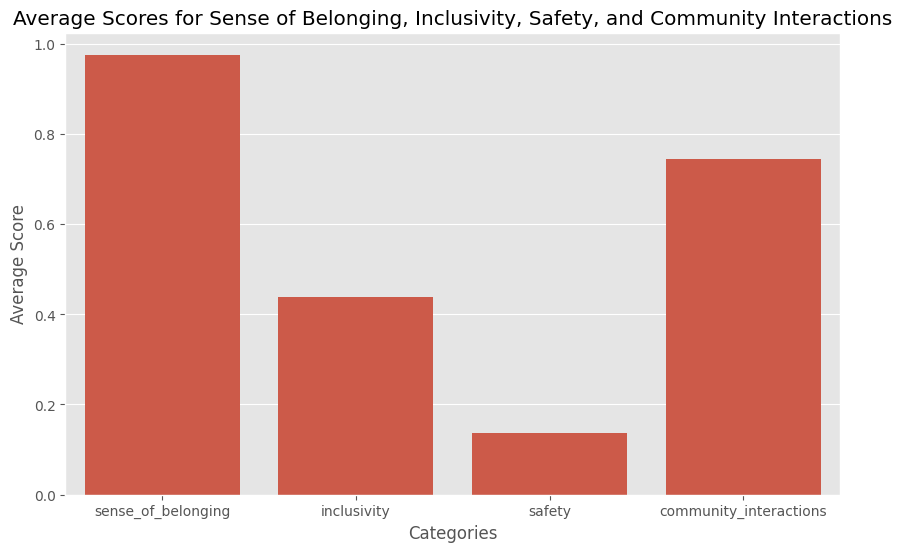

In [46]:
def classify_text(text):
    if text is None:
        # Return 0 scores for None values
        return 0, 0, 0, 0
    
    # Ensure text is a string (in case it is not)
    text = str(text)
    
    sense_of_belonging_score = sum([1 for keyword in sense_of_belonging_keywords if keyword in text.lower()])
    inclusivity_score = sum([1 for keyword in inclusivity_keywords if keyword in text.lower()])
    safety_score = sum([1 for keyword in safety_keywords if keyword in text.lower()])
    community_interactions_score = sum([1 for keyword in community_interaction_keywords if keyword in text.lower()])
    
    return sense_of_belonging_score, inclusivity_score, safety_score, community_interactions_score

# Apply the classification function to the 'translated_text' column in the DataFrame
df[['sense_of_belonging', 'inclusivity', 'safety', 'community_interactions']] = df['translated_text'].apply(lambda x: pd.Series(classify_text(x)))

# Display the updated DataFrame
print(df[['translated_text', 'sense_of_belonging', 'inclusivity', 'safety', 'community_interactions']].head())

# Plotting the scores for each text entry
scores = df[['sense_of_belonging', 'inclusivity', 'safety', 'community_interactions']].mean()

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=scores.index, y=scores.values)
plt.title('Average Scores for Sense of Belonging, Inclusivity, Safety, and Community Interactions')
plt.xlabel('Categories')
plt.ylabel('Average Score')
plt.show()

This keyword matching approach is quite limiting because either we need to create a massive keyword dictionary, or select more relevant words. More words does not equal better outcomes. From this analysis it looks like the vast majority of reviews are related to or within the domain of "Sense of Belonging"

2. Thematic Classification - Supervised classification using Transformers - Bertopic which is used below

3. Thematic Classification (Unsupervised) - Discover Latent Topics 

Latent Dirichlet Allocation (LDA) approach to topic modeling - probabilitistic 

In [47]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

df['translated_text'] = df['translated_text'].fillna('')

# Vectorize the cleaned reviews using CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['translated_text'])

# Apply LDA for topic modeling
lda = LatentDirichletAllocation(n_components=5, random_state=42)  # 3 topics, adjust as needed
lda.fit(X)

# Print the topics and the top words in each topic
n_top_words = 10
words = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    print(f"Topic #{topic_idx + 1}:")
    print(" ".join([words[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

Topic #1:
park lake place great beautiful dog lots walk leash dogs
Topic #2:
place community parking ice good nice activities lake time walk
Topic #3:
park lake place city little people market walk amazing beautiful
Topic #4:
park lake beautiful nice dog walking walk place great trout
Topic #5:
park lake great dog nice like area community dogs areas


In [48]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Preprocessing function
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())  # Lowercase and tokenize
    return ' '.join([word for word in tokens if word.isalpha() and word not in stop_words])

# Apply preprocessing to the text column
df['processed_text'] = df['translated_text'].apply(preprocess_text)

# Create a document-term matrix using CountVectorizer
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(df['processed_text'])

# Apply LDA with 3 topics
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(dtm)

# Extract topic keywords
def print_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        topics.append([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
    return topics

# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Extract topics
topics = print_topics(lda_model, feature_names, n_top_words=10)

# Assign top 3 topics to the DataFrame
topic_assignments = lda_model.transform(dtm).argmax(axis=1)
df['topic'] = topic_assignments

# Output results
print("Extracted Topics:")
for idx, topic_keywords in enumerate(topics):
    print(f"Topic {idx + 1}: {', '.join(topic_keywords)}")

print("\nDataFrame with topic assignments:")
print(df[['translated_text', 'topic']])


Extracted Topics:
Topic 1: park, walk, lake, place, beautiful, lots, great, like, kids, dogs
Topic 2: lake, park, place, community, nice, beautiful, great, family, trout, playground
Topic 3: park, dog, lake, great, market, summer, beach, area, nice, walk

DataFrame with topic assignments:
                                       translated_text  topic
0    "Visited John Hendry Park (Trout Lake Park) to...      0
1    A beautiful park , I love going in the fall se...      0
2    A beautiful park with a pond, playground and r...      0
3    A circular track good for walking, biking, jog...      1
4    A decent and well attended community city park...      0
..                                                 ...    ...
250  A vast lake, a quiet lakeside, close to homes,...      1
251  The rain turned the sidewalk into mud and was ...      2
252  Very beautiful - quiet river dam - walking her...      1
253  A very beautiful city park suitable for variou...      1
254  Trout Park has an elega

CLS Embeddings Approach - Topic Clustering using BERTopic

In [49]:
from transformers import AutoTokenizer, AutoModel
import torch

# Load pre-trained BERT model and tokenizer
model_name = "bert-base-uncased"  # Use any compatible BERT model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Function to generate CLS embeddings
def generate_cls_embeddings_from_column(df, text):
    embeddings = []
    for text in df[text]:
        # Tokenize the input
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
        
        # Pass inputs through the model
        outputs = model(**inputs)
        
        # Extract CLS token embedding (first token)
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().detach().numpy()
        embeddings.append(cls_embedding)
    
    return embeddings

# Generate CLS embeddings for the 'text' column
df['cls_embedding'] = generate_cls_embeddings_from_column(df, 'translated_text')

# Print the DataFrame with embeddings
print(df.head())
print('CLS Embeddings Created!')


   review_id                                name   author_title  \
0          1  John Hendry Park (Trout Lake Park)  Lucas Clearly   
1          2  John Hendry Park (Trout Lake Park)       sowjanya   
2          3  John Hendry Park (Trout Lake Park)     Rania Tan.   
3          4  John Hendry Park (Trout Lake Park)       Anson Li   
4          5  John Hendry Park (Trout Lake Park)    Karin Hatch   

               author_id                                        review_text  \
0  115109798485437495979  "Visited John Hendry Park (Trout Lake Park) to...   
1  100601097379534923033  A beautiful park , I love going in the fall se...   
2  116635854122359369671  A beautiful park with a pond, playground and r...   
3  118252211920789680978  A circular track good for walking, biking, jog...   
4  116725000188867424887  A decent and well attended community city park...   

   review_rating  review_datetime_utc review_questions_None  \
0              5  06/12/2024 10:42:27                   NaN

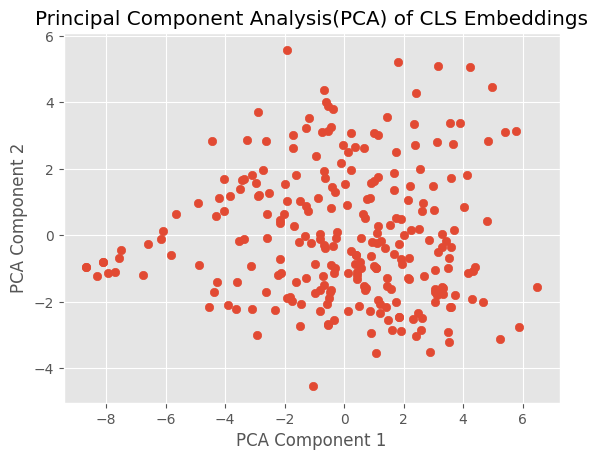

In [50]:
from sklearn.decomposition import PCA

# Convert the 'cls_embeddings' column (which may contain tensors or lists) to a NumPy array for PCA
embeddings = df['cls_embedding'].apply(lambda x: torch.tensor(x).numpy())  # If stored as a tensor
embeddings = np.vstack(embeddings)  # Convert list of arrays to a 2D array

# Apply PCA to reduce the embeddings to 2D --> can also try this with 3D 
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Plot the 2D PCA projection
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])
plt.title('Principal Component Analysis(PCA) of CLS Embeddings')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


In [51]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Extract features using TF-IDF to get term frequencies
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['processed_text'])

# Perform KMeans clustering (adjust n_clusters as needed)
n_clusters = 5  # Number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# Get the terms (words) from the vectorizer
terms = vectorizer.get_feature_names_out()

# Display top words for each cluster
top_n = 10  # Number of top words to display for each cluster
for i in range(n_clusters):
    print(f"\nCluster {i}:")
    # Get the indices of the terms associated with each cluster center
    cluster_center = kmeans.cluster_centers_[i]
    top_indices = cluster_center.argsort()[-top_n:][::-1]
    top_terms = [terms[idx] for idx in top_indices]
    print(", ".join(top_terms))



Cluster 0:
walk, park, place, scenery, nice, autumn, lake, perfect, time, enjoy

Cluster 1:
nice, park, lake, dog, little, like, space, picnic, excellent, friendly

Cluster 2:
park, kids, lake, leash, area, lots, dogs, great, small, like

Cluster 3:
beautiful, walking, park, place, suitable, lake, peaceful, quiet, running, cycling

Cluster 4:
great, park, market, place, farmers, city, love, lake, beach, dog


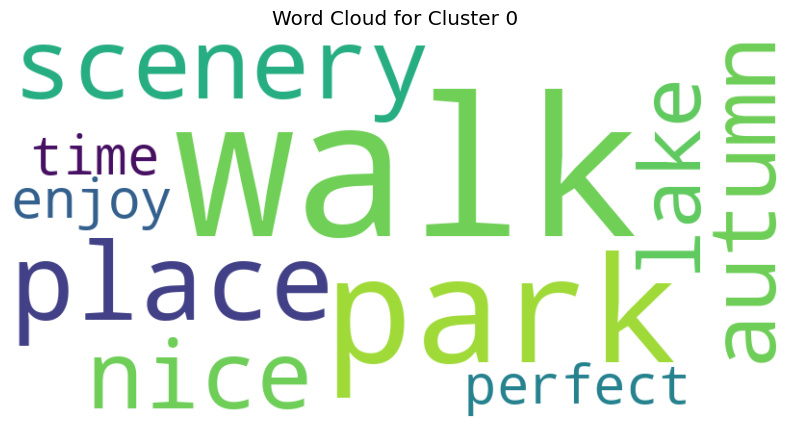

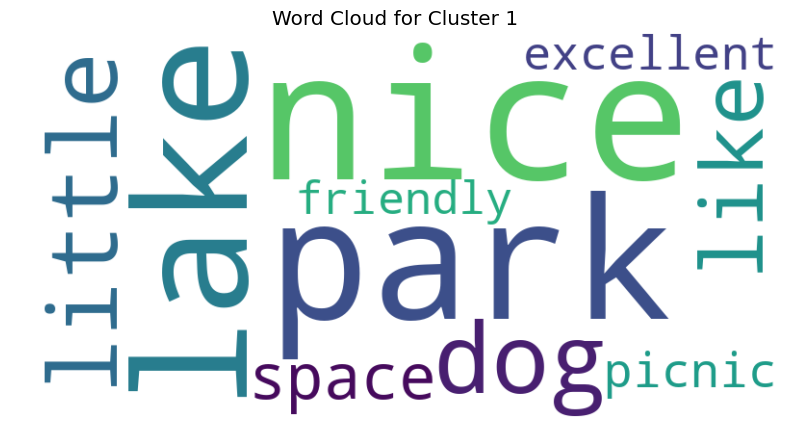

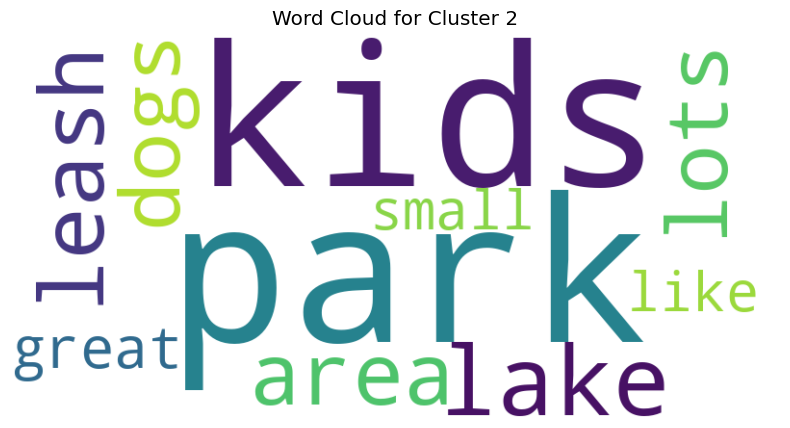

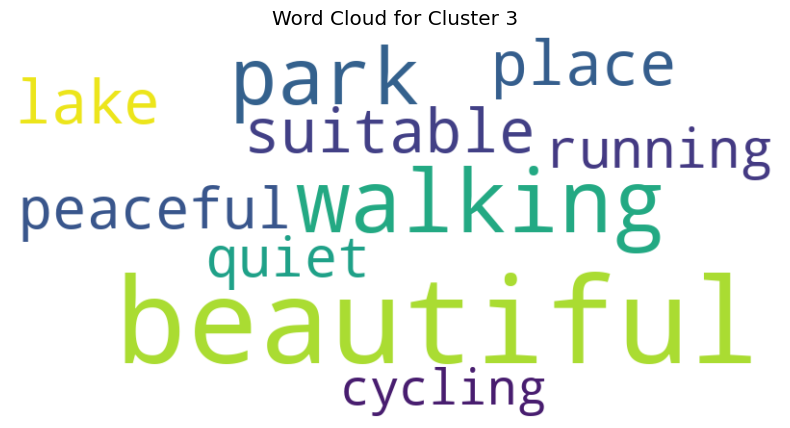

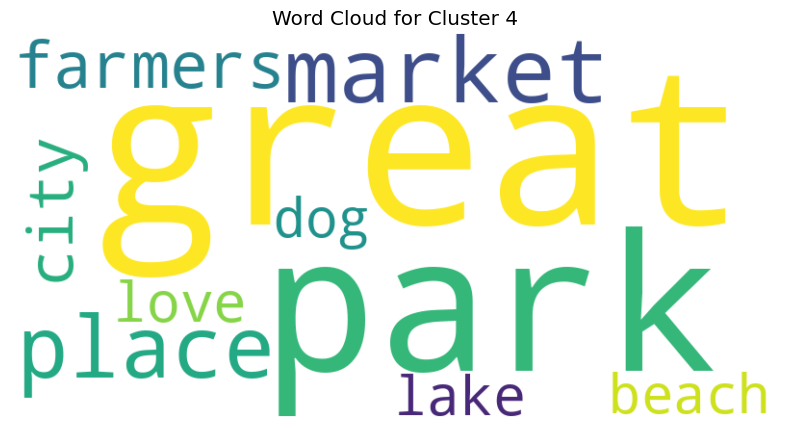

In [52]:
from wordcloud import WordCloud

# Generate word clouds for each cluster
for i in range(n_clusters):
    # Get the top terms for the cluster
    cluster_center = kmeans.cluster_centers_[i]
    top_indices = cluster_center.argsort()[-top_n:][::-1]
    top_terms = {terms[idx]: cluster_center[idx] for idx in top_indices}
    
    # Create a word cloud for the cluster
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_terms)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for Cluster {i}")
    plt.show()


In [53]:
#check which column to use, translated or processed text 
from bertopic import BERTopic
import umap 

# Extract CLS embeddings as a 2D array
cls_embeddings = np.vstack(df['cls_embedding'].values)

# Initialize BERTopic
topic_model = BERTopic()

# Fit BERTopic using the 'text' column and CLS embeddings
topics, probs = topic_model.fit_transform(df['processed_text'], cls_embeddings)

# Add topics back to the DataFrame
df['topic'] = topics

# View topic information
print(topic_model.get_topic_info())

# Visualize the top topics
topic_model.visualize_barchart(top_n_topics=10)


ImportError: cannot import name 'UMAP' from 'umap' (c:\Users\jialuzha.stu\.conda\envs\nlptest\Lib\site-packages\umap\__init__.py)